# L10 Modeling

- Models

- The **Model Process** (4 Steps)

- Choose A **Model**

- Choose A **Loss Function**

- **Fitting** The Model

- **Evaluating** The Model

## 1 Models

- Earlier, we have looked into the **early stages of the data science lifecycle**, focusing on the programming tools, visualization techniques, and data cleaning methods needed for data analysis

- This lec. shift the focus to actually using our data to better understand the world

- We will explore **predictive modeling**

<div style="background-color:#3b82f630; padding:12px 16px; border-left:5px solid #3b82f6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Definition:</strong> **Models & Systems**

- A **model** is an **idealized representation of a system**

- A **system** is a **set of principles or procedures** according to which something functions

</div>

- The workings of the world can be viewed as its own giant procedure

- Models seek to simplify the world and distill them into workable pieces

### Reasons for Building Models

- **Inference**: Make sense of phenomena

- **Prediction**: Make accurate predictions about unseen data

- **Causality**: Assess whether one thing causes something else

We try to balance between building **interpretable** models and building **accurate** models

### Common Types of Models

- **Deterministic physical (mechanistic) models**: Laws that govern how the world works

- **Probabilistic models**: Models that attempt to understand how random processes evolve

### *Simple Linear Regression

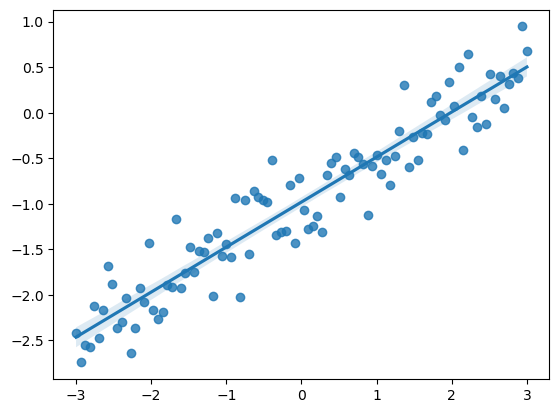

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Set random seed for consistency 
np.random.seed(43)
plt.style.use('default') 

# Generate random noise for plotting
x = np.linspace(-3, 3, 100)
y = x * 0.5 - 1 + np.random.randn(100) * 0.3

# Plot regression line
sns.regplot(x=x,y=y);

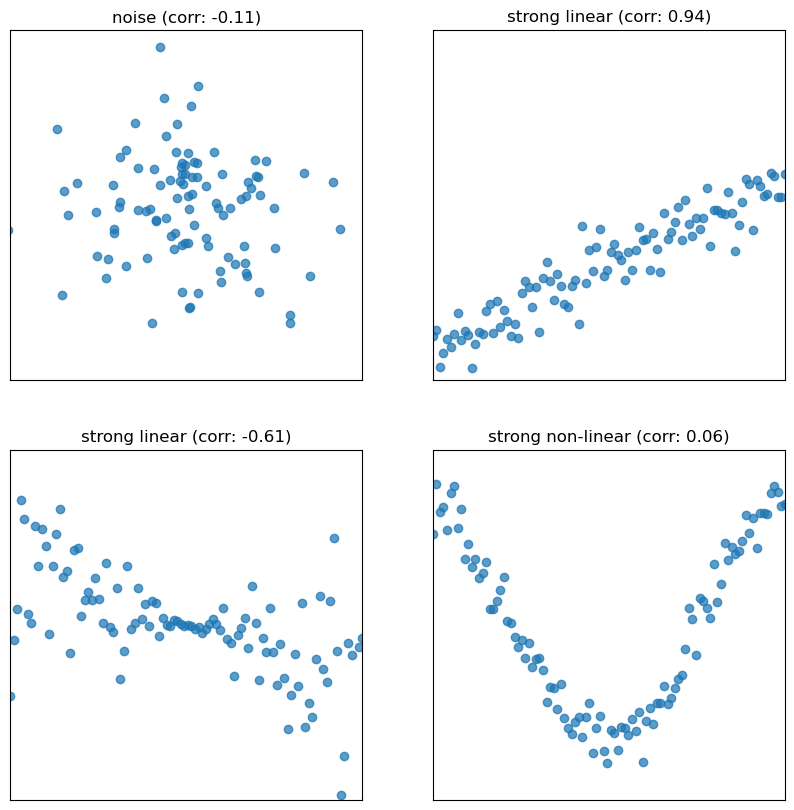

In [2]:
def plot_and_get_corr(ax, x, y, title):
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.scatter(x, y, alpha = 0.73)
    r = np.corrcoef(x, y)[0, 1]
    ax.set_title(title + " (corr: {})".format(r.round(2)))
    return r

fig, axs = plt.subplots(2, 2, figsize = (10, 10))

# Just noise
x1, y1 = np.random.randn(2, 100)
corr1 = plot_and_get_corr(axs[0, 0], x1, y1, title = "noise")

# Strong linear
x2 = np.linspace(-3, 3, 100)
y2 = x2 * 0.5 - 1 + np.random.randn(100) * 0.3
corr2 = plot_and_get_corr(axs[0, 1], x2, y2, title = "strong linear")

# Unequal spread
x3 = np.linspace(-3, 3, 100)
y3 = - x3/3 + np.random.randn(100)*(x3)/2.5
corr3 = plot_and_get_corr(axs[1, 0], x3, y3, title = "strong linear")
extent = axs[1, 0].get_window_extent().transformed(fig.dpi_scale_trans.inverted())

# Strong non-linear
x4 = np.linspace(-3, 3, 100)
y4 = 2*np.sin(x3 - 1.5) + np.random.randn(100) * 0.3
corr4 = plot_and_get_corr(axs[1, 1], x4, y4, title = "strong non-linear")

plt.show()

## 2 The Modeling Process

- We **use a subset of the variables in our sample** of collected data **to model another variable in this data**

- For each pair of values $(x_i, y_i)$ is one **observation**

  - $y_i$: **output / response**
  
  - $x_i$: **feature**


- We want to get $\hat{y} _i$ **prediction**

- How to generate these predictions?

	- Say for $\hat{y} _i = \theta_0 + \theta_1 x_i$

- This is a **parametric model**

  - Not all statistical models have parameters
  
    - KNN is a non-parametric model 

- The parameters $(\theta_0, \theta_1)$ are used to describe the relationship between $x_i$ & $\hat{y} _i$

- But we don't know the parameters

- We need to pick the optimal parameters through modeling process

- $\hat{\theta}$ is an estimate of $\theta$

**4 steps of modeling**

- **Choose a model**: How should we represent the world?

- **Choose a loss function**: How do we quantify prediction error?

  - Usually in the form of $L(y,\hat{y})$ for each pair
  
  - Common loss funcs
  
    - L2 Loss
    
	- L1 Loss
  
  - We want to understand how our model performs **across our entire dataset**
  
  - A way to do it is average $\hat{R}(\theta) = \frac{1}{n} \sum L(y_i,\hat{y}_i)$ **Cost Func / Empirical Risk / Error Func / Average Loss**

    - L2, Mean Squared Error (MSE)
    
	- L1, Mean Absolute Error (MAE)

- **Fit the model**: How do we choose the best parameters of our model given our data?

  - Minimize the cost func 

- **Evaluate model performance**: How do we evaluate whether this process gave rise to a good model?

  - RMSE, Root Mean Squared Error (RMSE)

---
[Reference](https://ds100.org/course-notes/modeling-slr/)